## Interpolation polynomiale : Lagrange, Newton, Hermite et runge's phenomen

### Module : Mathematics for AI
### Niveau : Master 1 Data & IA
### Nom et prénom : Abir Ben Harrou
### Date : 4 octobre 2026


In [71]:
import matplotlib.pyplot as plt
import numpy as np

In [72]:
# Methode de lagrange
def poly_lagrange(x_points, y_points, x):
    n = len(x_points)
    P=0
    for k in range(n):
        L=1
        for j in range(n):
            if (k!=j):
                L *= (x - x_points[j])/(x_points[k]-x_points[j])
        P += y_points[k] * L
    return P


In [73]:
# Methode de newton
def div_diff(x,y,i,j):
    if (i==j):
        return y[i]
    return (div_diff(x,y,i+1,j)-div_diff(x,y,i,j-1))/(x[j]-x[i])

def coeffs(x, y):
    return [div_diff(x,y,0,k) for k in range(len(x))]

def eval_newton(x_nodes, c, x):
    n = len(c) - 1
    p = c[n] * np.ones_like(x, dtype=float)
    for k in range(n-1, -1, -1):
        p = p * (x - x_nodes[k]) + c[k]
    return p

def poly_newton(x_points,y_points,x):
    c =coeffs(x_points,y_points)
    return eval_newton(x_points, c, x)


In [74]:
# methode de herrite
def dl_Lis(x_points,i):
    dl_Li=0
    for j in range(len(x_points)):
        if(j!=i):
            dl_Li += 1.0/(x_points[i]-x_points[j])
    return dl_Li

def Lis(x_points,i,x):
    Li=1
    for j in range(len(x_points)):
        if(j!=i):
            Li *= (x-x_points[j])/(x_points[i]-x_points[j])
    return Li

def His(x_points,i,x):
    Hi=0
    Hi=(1-2*(x-x_points[i])*dl_Lis(x_points,i))*(Lis(x_points,i,x)**2)
    return Hi

def H_chapeau(x_points,i,x):
    return (x-x_points[i])*(Lis(x_points,i,x)**2)

def hermite(x_points, y_points, x, dl_y):
    H=0
    for i in range(len(x_points)):
        H += y_points[i] * His(x_points,i,x) + dl_y[i] * H_chapeau(x_points,i,x)
    return H








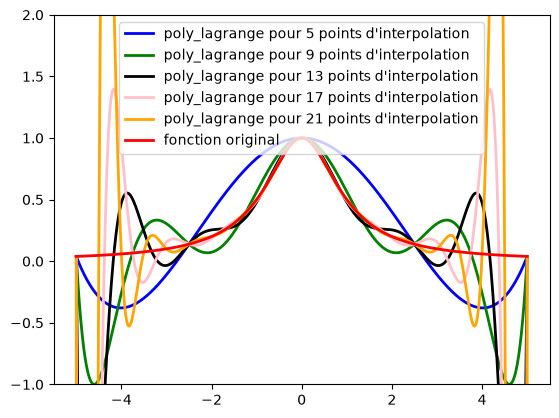

l'erreur pour 5 points d'interpolation :  0.43835262054180285
l'erreur pour 9 points d'interpolation :  1.045173911783697
l'erreur pour 13 points d'interpolation :  3.662996788618303
l'erreur pour 17 points d'interpolation :  14.386268436818982
l'erreur pour 21 points d'interpolation :  59.76832783988819


In [75]:
# test de lagrange sur la fonction 1 : f(x) = 1/(1+x²)
x=np.linspace(-5,5,1001)
y=1.0/(1+x**2)

xn = np.linspace(-5,5,5)
yn=1.0/(1+xn**2)

xn2 = np.linspace(-5,5,9)
yn2=1.0/(1+xn2**2)

xn3 = np.linspace(-5,5,13)
yn3=1.0/(1+xn3**2)

xn4 = np.linspace(-5,5,17)
yn4=1.0/(1+xn4**2)


xn5 = np.linspace(-5,5,21)
yn5=1.0/(1+xn5**2)
# 5, 9, 13, 17, 21

#construction du polynome pour chaque nombre de points
p = poly_lagrange(xn, yn , x)
p2 = poly_lagrange(xn2, yn2 , x)
p3= poly_lagrange(xn3, yn3 , x)
p4 = poly_lagrange(xn4, yn4 , x)
p5 = poly_lagrange(xn5, yn5 , x)

# réalisation de la courbe
plt.plot(x,p ,label="poly_lagrange pour 5 points d'interpolation",color='blue',linewidth=2)
plt.plot(x,p2,label="poly_lagrange pour 9 points d'interpolation",color='green',linewidth=2)
plt.plot(x,p3,label="poly_lagrange pour 13 points d'interpolation",color='black',linewidth=2)
plt.plot(x,p4,label="poly_lagrange pour 17 points d'interpolation",color='pink',linewidth=2)
plt.plot(x,p5,label="poly_lagrange pour 21 points d'interpolation",color='orange',linewidth=2)
plt.plot(x,y,label='fonction original',color='red',linewidth='2')
plt.legend()
plt.ylim(-1, 2)
plt.show()

#calcul de l'erreur pour chaque cas
err = np.max(np.abs(y - p))
print("l'erreur pour 5 points d'interpolation : ",err)
err2 = np.max(np.abs(y - p2))
print("l'erreur pour 9 points d'interpolation : ",err2)
err3 = np.max(np.abs(y - p3))
print("l'erreur pour 13 points d'interpolation : ",err3)
err4 = np.max(np.abs(y - p4))
print("l'erreur pour 17 points d'interpolation : ",err4)
err5 = np.max(np.abs(y - p5))
print("l'erreur pour 21 points d'interpolation : ",err5)


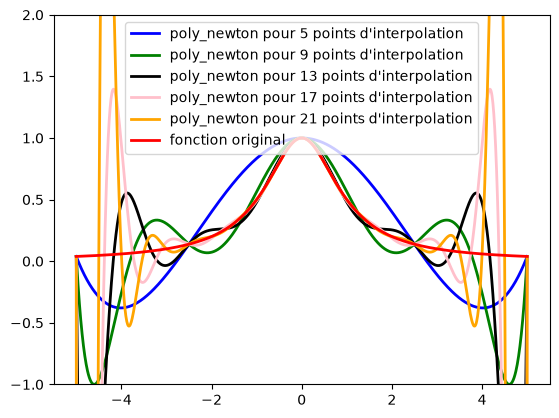

l'erreur pour 5 points d'interpolation :  0.43835262054180335
l'erreur pour 9 points d'interpolation :  1.045173911783703
l'erreur pour 13 points d'interpolation :  3.6629967886183046
l'erreur pour 17 points d'interpolation :  14.386268436822476
l'erreur pour 21 points d'interpolation :  59.768327839903954


In [76]:
# test de la methode de newton sur la fonction 1 : f(x) = 1/(1+x²)
x=np.linspace(-5,5,1001)
y=1.0/(1+x**2)

xn = np.linspace(-5,5,5)
xn2 = np.linspace(-5,5,9)
yn2=1.0/(1+xn2**2)
xn3 = np.linspace(-5,5,13)
yn3=1.0/(1+xn3**2)
xn4 = np.linspace(-5,5,17)
yn4=1.0/(1+xn4**2)
yn=1.0/(1+xn**2)
xn5 = np.linspace(-5,5,21)
yn5=1.0/(1+xn5**2)
# 5, 9, 13, 17, 21
p = poly_newton(xn, yn , x)
p2 = poly_newton(xn2, yn2 , x)
p3= poly_newton(xn3, yn3 , x)
p4 = poly_newton(xn4, yn4 , x)
p5 = poly_newton(xn5, yn5 , x)
plt.plot(x,p ,label="poly_newton pour 5 points d'interpolation",color='blue',linewidth=2)
plt.plot(x,p2,label="poly_newton pour 9 points d'interpolation",color='green',linewidth=2)
plt.plot(x,p3,label="poly_newton pour 13 points d'interpolation",color='black',linewidth=2)
plt.plot(x,p4,label="poly_newton pour 17 points d'interpolation",color='pink',linewidth=2)
plt.plot(x,p5,label="poly_newton pour 21 points d'interpolation",color='orange',linewidth=2)
plt.plot(x,y,label='fonction original',color='red',linewidth='2')
plt.legend()
plt.ylim(-1, 2)
plt.show()

err = np.max(np.abs(y - p))
print("l'erreur pour 5 points d'interpolation : ",err)
err2 = np.max(np.abs(y - p2))
print("l'erreur pour 9 points d'interpolation : ",err2)
err3 = np.max(np.abs(y - p3))
print("l'erreur pour 13 points d'interpolation : ",err3)
err4 = np.max(np.abs(y - p4))
print("l'erreur pour 17 points d'interpolation : ",err4)
err5 = np.max(np.abs(y - p5))
print("l'erreur pour 21 points d'interpolation : ",err5)


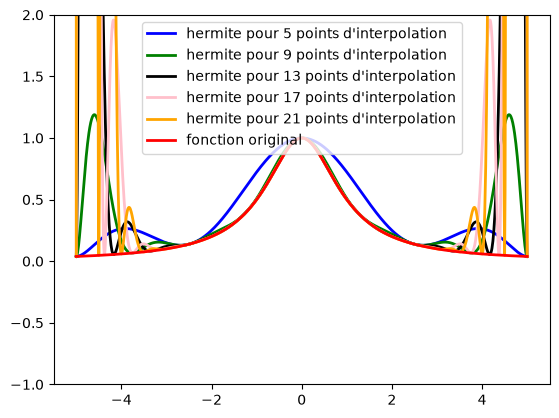

l'erreur pour 5 points d'interpolation :  0.2235785853905099
l'erreur pour 9 points d'interpolation :  1.1440136715572335
l'erreur pour 13 points d'interpolation :  14.009732883985675
l'erreur pour 17 points d'interpolation :  215.8244051017148
l'erreur pour 21 points d'interpolation :  3722.873583461488


In [77]:
# test de hermite
# sur la fonction 1 : f(x) = 1/(1+x²)


x=np.linspace(-5,5,1001)
y=1.0/(1+x**2)

xn = np.linspace(-5,5,5)
yn=1.0/(1+xn**2)
dyn = -2*xn/(1+xn**2)**2

xn2 = np.linspace(-5,5,9)
yn2=1.0/(1+xn2**2)
dyn2 = -2*xn2/(1+xn2**2)**2

xn3 = np.linspace(-5,5,13)
yn3=1.0/(1+xn3**2)
dyn3 = -2*xn3/(1+xn3**2)**2

xn4 = np.linspace(-5,5,17)
yn4=1.0/(1+xn4**2)
dyn4 = -2*xn4/(1+xn4**2)**2

xn5 = np.linspace(-5,5,21)
yn5=1.0/(1+xn5**2)
dyn5 = -2*xn5/(1+xn5**2)**2

# 5, 9, 13, 17, 21

# Construction du polynome hermite
# pour chaque nombre de points d'interpolation
p = hermite(xn, yn , x,dyn)
p2 = hermite(xn2, yn2 , x,dyn2)
p3= hermite(xn3, yn3 , x,dyn3)
p4 = hermite(xn4, yn4 , x, dyn4)
p5 = hermite(xn5, yn5 , x,dyn5)

# Réalisation de la courbe pour chaque point d'interpolation 
plt.plot(x,p ,label="hermite pour 5 points d'interpolation",color='blue',linewidth=2)
plt.plot(x,p2,label="hermite pour 9 points d'interpolation",color='green',linewidth=2)
plt.plot(x,p3,label="hermite pour 13 points d'interpolation",color='black',linewidth=2)
plt.plot(x,p4,label="hermite pour 17 points d'interpolation",color='pink',linewidth=2)
plt.plot(x,p5,label="hermite pour 21 points d'interpolation",color='orange',linewidth=2)
plt.plot(x,y,label='fonction original',color='red',linewidth='2')
plt.legend()
plt.ylim(-1, 2)
plt.show()

# Calcule de l'erreur pour chaque cas.
err = np.max(np.abs(y - p))
print("l'erreur pour 5 points d'interpolation : ",err)
err2 = np.max(np.abs(y - p2))
print("l'erreur pour 9 points d'interpolation : ",err2)
err3 = np.max(np.abs(y - p3))
print("l'erreur pour 13 points d'interpolation : ",err3)
err4 = np.max(np.abs(y - p4))
print("l'erreur pour 17 points d'interpolation : ",err4)
err5 = np.max(np.abs(y - p5))
print("l'erreur pour 21 points d'interpolation : ",err5)



feedback : function f(x) = 1/(1+x²)

For f(x) = 1/(1+x²) with equidistant points, the Lagrange and Newton polynomials are quite identical . As the number of points increases, the polynomial does not get closer to the function and the maximum error rises from 0.44 (5 points) to 59 (21 points). The polynomial approximates the function well near the center, but it oscillates strongly near the edges ±5, where the error is concentrated. This is Runge's phenomenon: increasing the number of points degrades the approximation.

The Hermite method behaves in the same way, but for an equal number of points the error grows much faster (3723 for 21 points). In all cases, Runge's phenomenon is observed with equidistant points.

In [78]:
# deuxieme fonction : sin(x)

x  = np.linspace(-np.pi, np.pi, 1001)
y= np.sin(x)

xn= np.linspace(-np.pi, np.pi,5)
yn=np.sin(xn)
dyn=np.cos(xn)

xn2= np.linspace(-np.pi, np.pi,9)
yn2=np.sin(xn2)
dyn2=np.cos(xn2)

xn3= np.linspace(-np.pi, np.pi,13)
yn3=np.sin(xn3)
dyn3=np.cos(xn3)

xn4= np.linspace(-np.pi, np.pi,17)
yn4=np.sin(xn4)
dyn4=np.cos(xn4)

xn5= np.linspace(-np.pi, np.pi,21)
yn5=np.sin(xn5)
dyn5=np.cos(xn5)

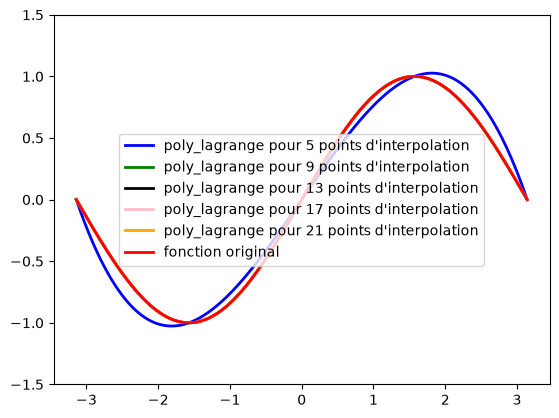

l'erreur pour 5 points d'interpolation :  0.18075817551181184
l'erreur pour 9 points d'interpolation :  0.0012055380604159283
l'erreur pour 13 points d'interpolation :  1.5887866854080723e-06
l'erreur pour 17 points d'interpolation :  6.653559786462537e-10
l'erreur pour 21 points d'interpolation :  1.4795803471301383e-12


In [79]:
# test de lagrange
p = poly_lagrange(xn,yn,x)
p2 = poly_lagrange(xn2,yn2,x)
p3 = poly_lagrange(xn3,yn3,x)
p4 = poly_lagrange(xn4,yn4,x)
p5 = poly_lagrange(xn5,yn5,x)


plt.plot(x,p ,label="poly_lagrange pour 5 points d'interpolation",color='blue',linewidth=2)
plt.plot(x,p2,label="poly_lagrange pour 9 points d'interpolation",color='green',linewidth=2)
plt.plot(x,p3,label="poly_lagrange pour 13 points d'interpolation",color='black',linewidth=2)
plt.plot(x,p4,label="poly_lagrange pour 17 points d'interpolation",color='pink',linewidth=2)
plt.plot(x,p5,label="poly_lagrange pour 21 points d'interpolation",color='orange',linewidth=2)
plt.plot(x,y,label='fonction original',color='red',linewidth='2')
plt.legend()
plt.ylim(-1.5, 1.5)
plt.show()

err = np.max(np.abs(y - p))
print("l'erreur pour 5 points d'interpolation : ",err)
err2 = np.max(np.abs(y - p2))
print("l'erreur pour 9 points d'interpolation : ",err2)
err3 = np.max(np.abs(y - p3))
print("l'erreur pour 13 points d'interpolation : ",err3)
err4 = np.max(np.abs(y - p4))
print("l'erreur pour 17 points d'interpolation : ",err4)
err5 = np.max(np.abs(y - p5))
print("l'erreur pour 21 points d'interpolation : ",err5)


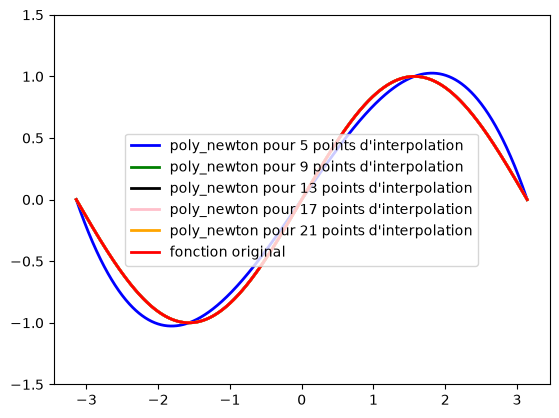

l'erreur pour 5 points d'interpolation :  0.18075817551181195
l'erreur pour 9 points d'interpolation :  0.0012055380604160948
l'erreur pour 13 points d'interpolation :  1.5887866791630678e-06
l'erreur pour 17 points d'interpolation :  6.653167877734845e-10
l'erreur pour 21 points d'interpolation :  1.2879974864432597e-13


In [80]:
# test de newton

p = poly_newton(xn,yn,x)
p2 = poly_newton(xn2,yn2,x)
p3 = poly_newton(xn3,yn3,x)
p4 = poly_newton(xn4,yn4,x)
p5 = poly_newton(xn5,yn5,x)


plt.plot(x,p ,label="poly_newton pour 5 points d'interpolation",color='blue',linewidth=2)
plt.plot(x,p2,label="poly_newton pour 9 points d'interpolation",color='green',linewidth=2)
plt.plot(x,p3,label="poly_newton pour 13 points d'interpolation",color='black',linewidth=2)
plt.plot(x,p4,label="poly_newton pour 17 points d'interpolation",color='pink',linewidth=2)
plt.plot(x,p5,label="poly_newton pour 21 points d'interpolation",color='orange',linewidth=2)
plt.plot(x,y,label='fonction original',color='red',linewidth='2')
plt.legend()
plt.ylim(-1.5, 1.5)
plt.show()

err = np.max(np.abs(y - p))
print("l'erreur pour 5 points d'interpolation : ",err)
err2 = np.max(np.abs(y - p2))
print("l'erreur pour 9 points d'interpolation : ",err2)
err3 = np.max(np.abs(y - p3))
print("l'erreur pour 13 points d'interpolation : ",err3)
err4 = np.max(np.abs(y - p4))
print("l'erreur pour 17 points d'interpolation : ",err4)
err5 = np.max(np.abs(y - p5))
print("l'erreur pour 21 points d'interpolation : ",err5)


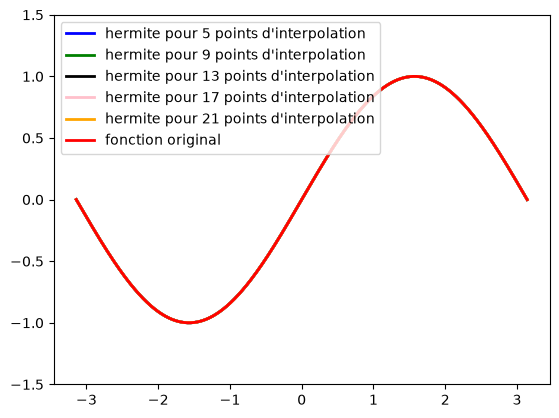

l'erreur pour 5 points d'interpolation :  6.41800712327667e-05
l'erreur pour 9 points d'interpolation :  6.746520009315304e-12
l'erreur pour 13 points d'interpolation :  9.698908343125368e-13
l'erreur pour 17 points d'interpolation :  1.2691903084061096e-10
l'erreur pour 21 points d'interpolation :  2.835995152605797e-08


In [81]:
#hermite


p = hermite(xn, yn , x,dyn)
p2 = hermite(xn2, yn2 , x,dyn2)
p3= hermite(xn3, yn3 , x,dyn3)
p4 = hermite(xn4, yn4 , x, dyn4)
p5 = hermite(xn5, yn5 , x,dyn5)

plt.plot(x,p ,label="hermite pour 5 points d'interpolation",color='blue',linewidth=2)
plt.plot(x,p2,label="hermite pour 9 points d'interpolation",color='green',linewidth=2)
plt.plot(x,p3,label="hermite pour 13 points d'interpolation",color='black',linewidth=2)
plt.plot(x,p4,label="hermite pour 17 points d'interpolation",color='pink',linewidth=2)
plt.plot(x,p5,label="hermite pour 21 points d'interpolation",color='orange',linewidth=2)
plt.plot(x,y,label='fonction original',color='red',linewidth='2')
plt.legend()
plt.ylim(-1.5, 1.5)
plt.show()

err = np.max(np.abs(y - p))
print("l'erreur pour 5 points d'interpolation : ",err)
err2 = np.max(np.abs(y - p2))
print("l'erreur pour 9 points d'interpolation : ",err2)
err3 = np.max(np.abs(y - p3))
print("l'erreur pour 13 points d'interpolation : ",err3)
err4 = np.max(np.abs(y - p4))
print("l'erreur pour 17 points d'interpolation : ",err4)
err5 = np.max(np.abs(y - p5))
print("l'erreur pour 21 points d'interpolation : ",err5)


feedback : function f(x) = sin(x)

For f(x) = sin(x) with equidistant points, the Lagrange and Newton polynomials give the same errors. The maximum error decreases steadily as the number of points increases, from 0.18 (5 points) to 1.6×10⁻⁶ (13 points). The polynomial stays close to the function over the whole interval, including near the edges, and no oscillations appear. Runge's phenomenon is therefore not observed for this function.

The Hermite method shows the same behavior: the error also decreases, and it is much smaller than Lagrange's for the same number of points (6.7×10⁻¹² versus 1.2×10⁻³ with 9 points).

Compared to f(x) = 1/(1+x²), where the error grows from 0.44 to 59 with the same equidistant points, this shows that Runge's phenomenon does not depend only on the number of points or on the method. It also depends on the function.

Conclusion :
    Runge's phenomenon occurs when increasing the number of equidistant interpolation points makes the approximation worse instead of better. The polynomial fits the function well near the center of the interval, but it oscillates strongly near the edges, and the maximum error grows as the degree increases.